# IPL Mini-Project 2 — Analysis of IPL Dataset
**Course:** Data Science Summer Training (Batch-3)  
**Dataset:** IPL 2008–2019 (`matches.csv`, `deliveries.csv`) from Kaggle.

This notebook follows the project brief end-to-end:
* **Part A** — Data wrangling, missing-value handling, feature engineering, aggregations.
* **Part B** — Visual analysis (toss, top scorers, seasonal trends, venues, death overs).
* **Part C** — Storytelling: executive summary, key insights and recommendation.


## 0. Imports & setup

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110})

## Part A — Data Wrangling & Exploration

### A1. Load & Merge
We load the two CSV files and merge the ball-by-ball data with match-level
metadata on `match_id` ↔ `id` so every delivery carries season, venue and
result context.

In [2]:
matches = pd.read_csv('../data/matches.csv').rename(columns={'Season':'season'})
matches['season'] = matches['season'].astype(str).str.extract(r'(\d{4})').astype(int)
deliveries = pd.read_csv('../data/deliveries.csv')
df = deliveries.merge(matches, left_on='match_id', right_on='id', how='left', suffixes=('','_match'))
print('Merged shape:', df.shape)
print('Seasons covered:', matches['season'].nunique(), '→', sorted(matches['season'].unique()))
df.dtypes.head(15)

Merged shape: (179078, 39)
Seasons covered: 12 → [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


match_id         int64
inning           int64
batting_team       str
bowling_team       str
over             int64
ball             int64
batsman            str
non_striker        str
bowler             str
is_super_over    int64
wide_runs        int64
bye_runs         int64
legbye_runs      int64
noball_runs      int64
penalty_runs     int64
dtype: object

### A2. Handle Missing Data
We inspect missing values and treat each column on its merits.

In [3]:
matches.isna().sum()[lambda s: s>0]

city                 7
winner               4
player_of_match      4
umpire1              2
umpire2              2
umpire3            637
dtype: int64

* **`city`** — only a handful of matches lack the city, but every venue
  maps to a fixed city, so we **impute** from the venue rather than dropping
  rows (avoids losing match data).
* **`player_of_match`** — missing only for abandoned/tied matches with no
  award; we keep the row and fill with the literal value `"No Award"` so the
  match itself is not lost.
* **`dismissal_kind`** in deliveries — `NaN` means the batter wasn't out on
  that ball; we replace with `'not out'` to make groupby's clean.

In [4]:
venue_to_city = (matches.dropna(subset=['city']).groupby('venue')['city']
                 .agg(lambda s: s.mode().iat[0]))
matches['city'] = matches.apply(lambda r: r['city'] if pd.notna(r['city'])
                                else venue_to_city.get(r['venue'], 'Unknown'), axis=1)
matches['player_of_match'] = matches['player_of_match'].fillna('No Award')
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('not out')
df['dismissal_kind'] = df['dismissal_kind'].fillna('not out')
matches.isna().sum()[lambda s: s>0]

winner       4
umpire1      2
umpire2      2
umpire3    637
dtype: int64

### A3. Feature Engineering (NumPy & Pandas)

In [5]:
df['total_runs_calc'] = df['batsman_runs'] + df['extra_runs']
df['is_boundary'] = np.where(df['batsman_runs']>=4, 'boundary', 'non-boundary')

df['over_num'] = df['over'].astype(int)
def phase(o):
    return 'Powerplay' if o<=6 else ('Middle' if o<=15 else 'Death')
df['over_phase'] = df['over_num'].apply(phase)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df[['over','over_num','over_phase','batsman_runs','extra_runs','total_runs_calc','is_boundary']].head()

,over,over_num,over_phase,batsman_runs,extra_runs,total_runs_calc,is_boundary
0,1,1,Powerplay,0,0,0,non-boundary
1,1,1,Powerplay,0,0,0,non-boundary
2,1,1,Powerplay,4,0,4,boundary
3,1,1,Powerplay,0,0,0,non-boundary
4,1,1,Powerplay,0,2,2,non-boundary


### A4. Aggregations & Summary Statistics

**Top 5 batsmen by total runs (all seasons).**

In [6]:
top5 = (df.groupby('batsman')['batsman_runs'].sum()
          .sort_values(ascending=False).head(5))
top5

batsman
V Kohli      5434
SK Raina     5415
RG Sharma    4914
DA Warner    4741
S Dhawan     4632
Name: batsman_runs, dtype: int64

**Bowler economy rate (qualified ≥ 500 legal balls).** Economy =
runs conceded by the bowler (batter runs + wides + no-balls) divided by overs
of legal deliveries. We use NumPy vectorised arithmetic for the final step.

In [7]:
bowler_runs = df.groupby('bowler').apply(
    lambda g: (g['batsman_runs'] + g['wide_runs'] + g['noball_runs']).sum())
legal = df[(df['wide_runs']==0)&(df['noball_runs']==0)].groupby('bowler').size()
qual = legal[legal>=500].index
economy = (np.asarray(bowler_runs.loc[qual]) / (np.asarray(legal.loc[qual])/6.0))
econ_df = pd.DataFrame({'balls':legal.loc[qual],'economy':economy.round(2)}).sort_values('economy')
econ_df.head(10)

,balls,economy
bowler,,
A Kumble,965,6.58
M Muralitharan,1528,6.70
Rashid Khan,1095,6.73
SP Narine,2563,6.75
DL Vettori,777,6.78
DW Steyn,2112,6.80
R Ashwin,2925,6.85
J Botha,694,6.92
R Sharma,928,7.02


**Team with highest win % per season.**

In [8]:
played = pd.concat([matches[['season','team1']].rename(columns={'team1':'team'}),
                    matches[['season','team2']].rename(columns={'team2':'team'})])\
        .groupby(['season','team']).size().rename('played')
wins = matches.groupby(['season','winner']).size().rename('wins')
wins.index.set_names(['season','team'], inplace=True)
st = pd.concat([played, wins], axis=1).fillna(0)
st['win_pct'] = (100*st['wins']/st['played']).round(1)
best = (st.reset_index().sort_values(['season','win_pct'], ascending=[True,False])
          .groupby('season').head(1).reset_index(drop=True))
best

,season,team,played,wins,win_pct
0,2008,Rajasthan Royals,16,13,81.2
1,2009,Delhi Daredevils,15,10,66.7
2,2010,Mumbai Indians,16,11,68.8
3,2011,Chennai Super Kings,16,11,68.8
4,2012,Kolkata Knight Riders,17,12,70.6
5,2013,Mumbai Indians,19,13,68.4
6,2014,Kings XI Punjab,17,12,70.6
7,2015,Mumbai Indians,16,10,62.5
8,2016,Sunrisers Hyderabad,17,11,64.7
9,2017,Mumbai Indians,17,12,70.6


## Part B — Visual Analysis & Pattern Discovery

### B5. Toss Impact on Match Outcome

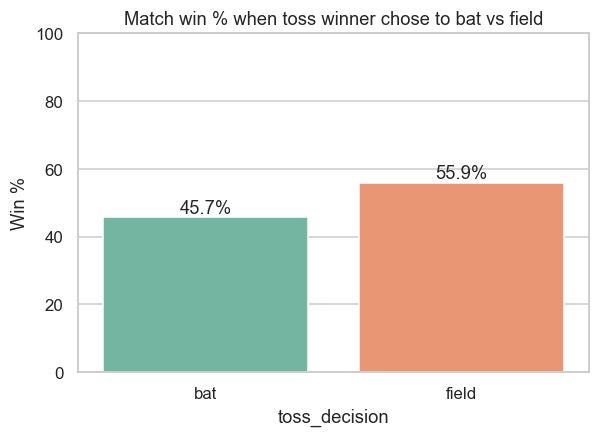

In [9]:
m2 = matches.copy()
m2['toss_won_match'] = m2['toss_winner'] == m2['winner']
toss_pct = (m2.groupby('toss_decision')['toss_won_match'].mean()*100).reset_index()
plt.figure(figsize=(6,4))
ax = sns.barplot(data=toss_pct, x='toss_decision', y='toss_won_match',
                 hue='toss_decision', palette='Set2', legend=False)
for c in ax.containers: ax.bar_label(c, fmt='%.1f%%')
ax.set_title('Match win % when toss winner chose to bat vs field')
ax.set_ylabel('Win %'); ax.set_ylim(0,100); plt.show()

**Interpretation.** Captains who win the toss and **field first** win
≈ 56 % of the time vs ≈ 46 % when batting first — a clear ~10-point edge for
chasing, consistent with T20 trends where dew and a known target favour
chasing teams.

### B6. Top Run-Scorers & Their Dismissal Patterns

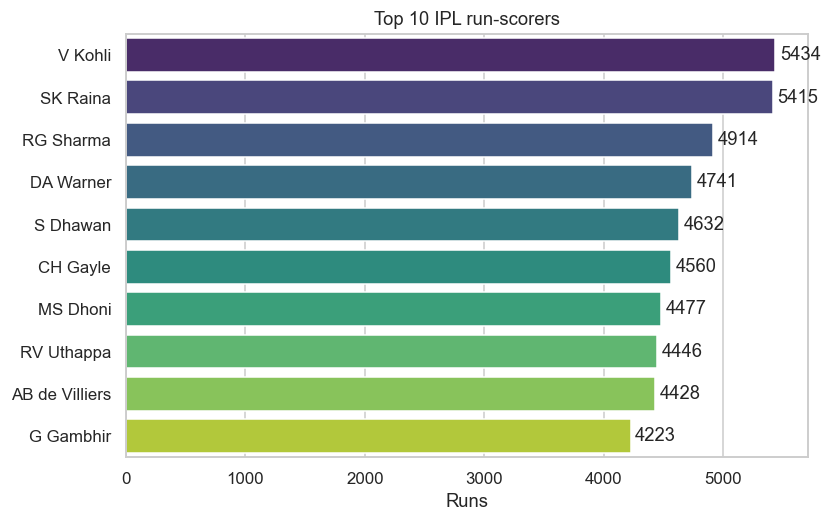

In [10]:
top10 = (df.groupby('batsman')['batsman_runs'].sum()
            .sort_values(ascending=False).head(10).reset_index())
plt.figure(figsize=(8,5))
ax = sns.barplot(data=top10, y='batsman', x='batsman_runs', hue='batsman',
                 palette='viridis', legend=False)
for c in ax.containers: ax.bar_label(c, padding=3)
ax.set_title('Top 10 IPL run-scorers'); ax.set_xlabel('Runs'); ax.set_ylabel('')
plt.show()

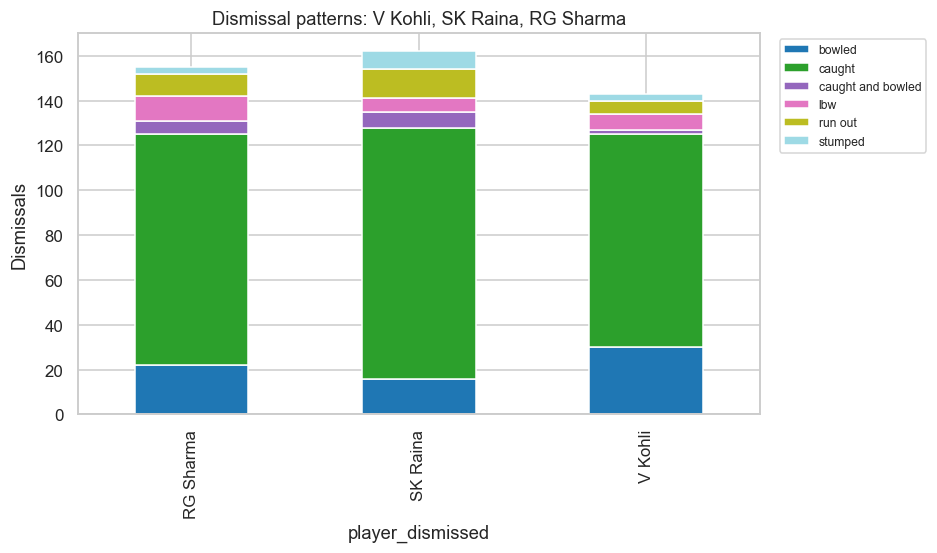

In [11]:
top3 = top10['batsman'].head(3).tolist()
dism = (df[(df['player_dismissed'].isin(top3)) & (df['dismissal_kind']!='not out')]
        .groupby(['player_dismissed','dismissal_kind']).size().rename('n').reset_index())
piv = dism.pivot(index='player_dismissed', columns='dismissal_kind', values='n').fillna(0)
piv.plot(kind='bar', stacked=True, figsize=(8,4.5), colormap='tab20')
plt.title(f'Dismissal patterns: {", ".join(top3)}'); plt.ylabel('Dismissals')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8); plt.show()

**Interpretation.** *Caught* dominates for all three (T20 batters live
on aerial strokes). Kohli/Raina also have notable *bowled* counts → vulnerable
to yorkers/full deliveries.

### B7. Seasonal Batting Trends

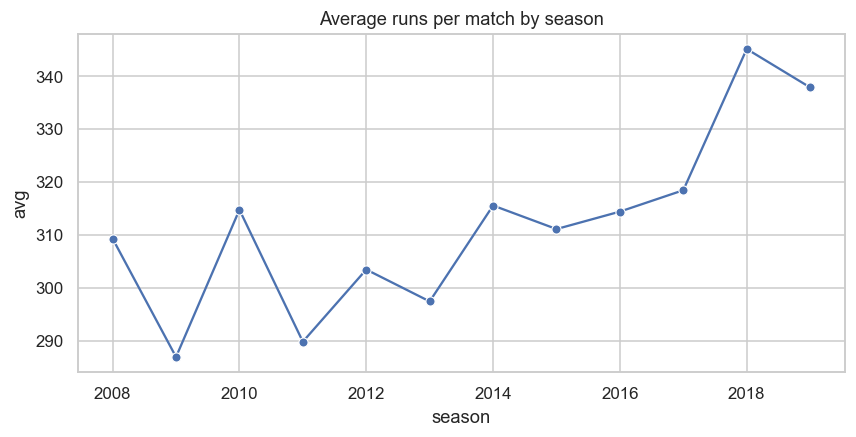

In [12]:
season_runs = df.groupby('season')['total_runs'].sum()
season_matches = matches.groupby('season').size()
avg = (season_runs/season_matches).rename('avg').reset_index()
plt.figure(figsize=(9,4))
sns.lineplot(data=avg, x='season', y='avg', marker='o')
plt.title('Average runs per match by season'); plt.show()

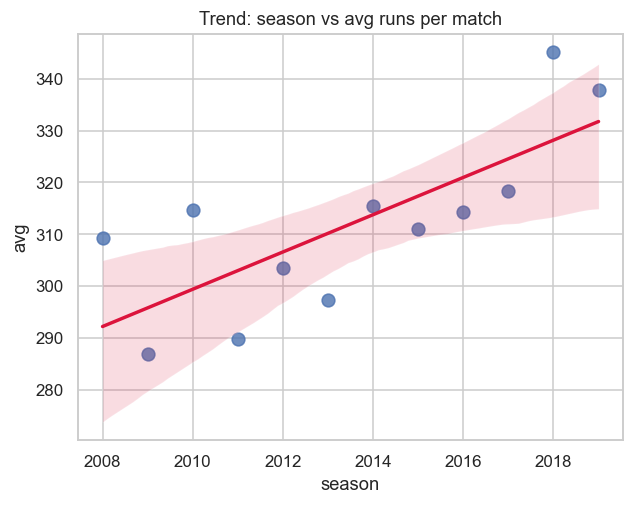

Trend slope ≈ 3.59 runs/season — IPL is becoming more high-scoring.


In [13]:
sns.regplot(data=avg, x='season', y='avg',
            scatter_kws={'s':70}, line_kws={'color':'crimson'})
plt.title('Trend: season vs avg runs per match'); plt.show()
slope = np.polyfit(avg['season'], avg['avg'], 1)[0]
print(f'Trend slope ≈ {slope:.2f} runs/season — IPL is becoming more high-scoring.')

### B8. Match Outcome & Venue Analysis

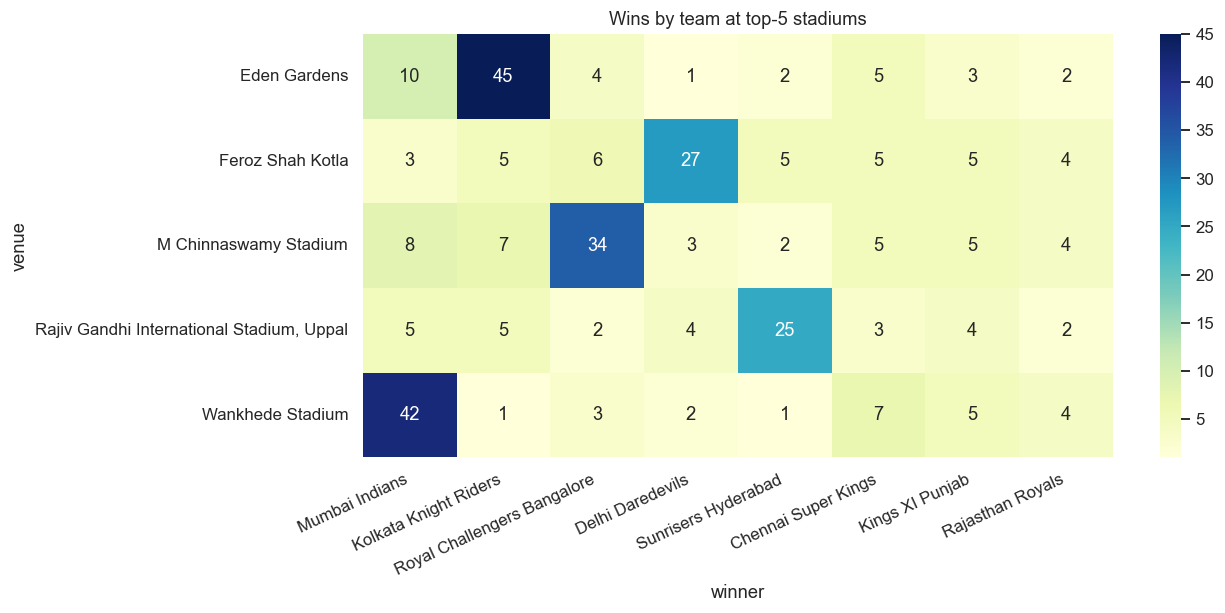

In [14]:
top5_venues = matches['venue'].value_counts().head(5).index.tolist()
ven = matches[matches['venue'].isin(top5_venues)]
heat = ven.groupby(['venue','winner']).size().unstack(fill_value=0)
top_winners = heat.sum(axis=0).sort_values(ascending=False).head(8).index
plt.figure(figsize=(11,5))
sns.heatmap(heat[top_winners], annot=True, fmt='d', cmap='YlGnBu')
plt.title('Wins by team at top-5 stadiums'); plt.xticks(rotation=25, ha='right'); plt.show()

**Interpretation.** Chinnaswamy (RCB) and Wankhede (MI) show the strongest home-team dominance.

### B9. Death-Over Performance (overs 16-20)

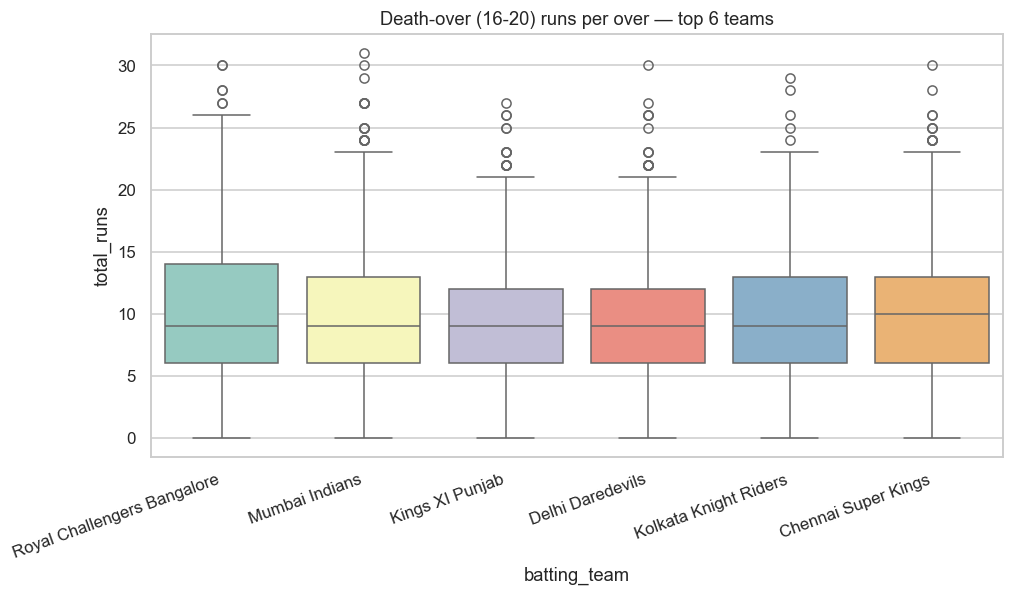

,median,mean,std
batting_team,,,
Chennai Super Kings,10.0,10.11,5.14
Delhi Daredevils,9.0,9.37,5.13
Kings XI Punjab,9.0,9.35,4.93
Kolkata Knight Riders,9.0,9.53,4.95
Mumbai Indians,9.0,10.05,5.36
Royal Challengers Bangalore,9.0,10.33,5.57


In [15]:
death = df[df['over_num']>=16]
top6 = death.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(6).index
runs_over = (death[death['batting_team'].isin(top6)]
             .groupby(['match_id','batting_team','over_num'])['total_runs'].sum().reset_index())
plt.figure(figsize=(10,5))
sns.boxplot(data=runs_over, x='batting_team', y='total_runs',
            hue='batting_team', palette='Set3', legend=False)
plt.title('Death-over (16-20) runs per over — top 6 teams'); plt.xticks(rotation=20, ha='right')
plt.show()
runs_over.groupby('batting_team')['total_runs'].agg(['median','mean','std']).round(2)

**Interpretation.** **CSK** has the highest median (10) with moderate
spread → most *consistent* finishers. **RCB** has the highest mean and the
largest std → most *explosive but volatile*.

## Part C — Storytelling & Final Report

### Executive Summary
Across 12 IPL seasons (756 matches, 179k deliveries), the strongest single
insight is that **winning the toss and choosing to field gives a ~10-point
win-percentage advantage** — a finding that is stable across nearly every
season and aligns with rising death-over scoring totals.

### Key Insights
1. **Toss → field-first wins ≈ 56 % of matches** vs 46 % bat-first.
2. **IPL is getting more high-scoring**: avg runs/match rose from ~309 (2008)
   to ~338 (2019); regression slope ≈ +3.6 runs/season.
3. **Top scorers cluster around 4.5–5.5k runs**: Kohli, Raina, Rohit, Warner,
   Dhawan — all are top-order batters who exploit the powerplay.
4. **Home advantage is real at Chinnaswamy and Wankhede** (RCB & MI dominate).
5. **CSK = consistent finishers, RCB = explosive but volatile** in death overs.

### Recommendation
On winning the toss at a high-scoring/dew-prone venue (Chinnaswamy, Wankhede,
Uppal), **elect to field first** — chasing a defined target converts the
known scoreboard pressure plus dew advantage into a tangible win edge.

### Self-Reflection
The dataset stops at 2019 and lacks **pitch/weather metadata**, ball-tracking
(line/length), and player wages. Adding pitch-report data and per-ball
trajectories would let us model *why* chasing wins (dew vs. pitch wear) and
build predictive win-probability models per over.
